In [1]:
from vaccination_functions import *
from acs_data_functions import *

In [2]:
import seaborn as sns

In [3]:
data_path = "../feature_inputs/"

enroll_regr = pd.read_csv(data_path+"acs_enrollment_percent_regression.csv")
enroll_edu_regr = pd.read_csv(data_path+"acs_enroll_education_percent_regression.csv")
eeli_regr = pd.read_csv(data_path+"acs_enroll_edu_lang_insurance_percent_regression.csv")

enroll_biClass_p53 = pd.read_csv(data_path+"acs_enrollment_percent_biClass_53p1_percent.csv")
enroll_edu_biClass_p53 = pd.read_csv(data_path+"acs_enroll_edu_percent_biClass_53p1_percent.csv")
eeli_biClass_p53 = pd.read_csv(data_path+"acs_enroll_edu_lang_insurance_percent_biClass_53p1_percent.csv")

In [4]:
drop_columns_corr = ['County', 'MMR Vaccination Rate']

In [5]:
enroll_num_feats_dict, enroll_regr_corr_reduced, enroll_corr_dropped_cols = determine_corr_feats(enroll_regr, drop_columns_corr)

75 intital features, reduced to 45 features


In [6]:
enroll_edu_num_feats_dict, enroll_edu_regr_corr_reduced, enroll_edu_corr_dropped_cols = determine_corr_feats(enroll_edu_regr, drop_columns_corr)

99 intital features, reduced to 68 features


In [7]:
eeli_num_feats_dict, eeli_regr_corr_reduced, eeli_corr_dropped_cols = determine_corr_feats(eeli_regr, drop_columns_corr)

99 intital features, reduced to 68 features


In [4]:
custom_y_ticks_75_100 = np.arange(75, 101, 2.5)
custom_y_ticks_60_100 = np.arange(60, 101, 2.5)
custom_x_ticks_0_100 = np.arange(0, 101, 5)
custom_x_ticks = np.arange(5, 101, 5)

XGB Regression

In [9]:
#n_estimators, learning_rate, max_depth, min_child_weight
enroll_xgb_params = {'learning_rate': 0.074, 'n_estimators': 105,  'max_depth': 5, 'min_child_weight': 2}
all_boost_regr_percent_df, boost_regr_perform_dict, y_regr_boost_results = ml_alogrithm_analysis(enroll_regr, model_type="Boost", drop_columns=['County'], 
                                                                                  hyper_params=enroll_xgb_params, algorithm_type="Regression")

Mean Absolute Error = 5.833916609159744, R2 = -0.057492049125819955


In [ ]:
#plot_vac_rates_predicted_actual(y_regr_boost_results, reg_type="Boost")
#plt.title("ACS Enrollment Features GradientBoost Regression MMR Vacination Rates")
#plt.ylim(75, 101)
#plt.yticks(custom_y_ticks_75_100)
#plt.xlim(5, 101)
#plt.xticks(custom_x_ticks)
#plt.savefig('../plots/gBoost_regression_vac_rates_acs_enrollment_features_actual_predict.png', bbox_inches="tight")

In [7]:
all_boost_regr_percent_df_enroll_edu, boost_regr_perform_dict_enroll_edu, y_regr_boost_results_enroll_edu = ml_alogrithm_analysis(enroll_edu_regr, model_type="Boost", drop_columns=['County'], 
                                                                                  hyper_params=enroll_xgb_params, algorithm_type="Regression")

Mean Absolute Error = 5.68825800569556, R2 = -0.07908660720930238


In [ ]:
#plt.hist(y_regr_boost_results_enroll_edu['test'], color='blue', label='Actual', bins=50)
#plt.title("ACS Enroll-Edu Feats GradientBoost Regression")
#plt.xlabel('MMR Vaccination Rates')
#plt.legend()
#plt.grid()

In [ ]:
#plot_vac_rates_predicted_actual(y_regr_boost_results_enroll_edu, reg_type="RandomForest")
#plt.title("ACS Enroll-Edu Features GradientBoost Regression MMR Vacination Rates")
#plt.ylim(60, 101)
#plt.yticks(custom_y_ticks_60_100)
#plt.xlim(5, 101)
#plt.xticks(custom_x_ticks)

In [8]:
all_boost_regr_percent_df_enroll_edu_dis_lan_insur, boost_regr_perform_dict_enroll_edu_dis_lan_insur, y_regr_boost_results_enroll_edu_dis_lan_insur = ml_alogrithm_analysis(eeli_regr, model_type="Boost", drop_columns=['County'], 
                                                                                   hyper_params=enroll_xgb_params, algorithm_type="Regression")

Mean Absolute Error = 5.986372609934506, R2 = -0.06123579661034384


In [ ]:
#plt.hist(y_regr_boost_results_enroll_edu_dis_lan_insur['test'], color='blue', label='Actual', bins=50)
#plt.hist(y_regr_boost_results_enroll_edu_dis_lan_insur['predict'], color='orange', label='Prediction', bins=50)
#plt.title("ACS Enroll-Edu-Dis-Lang-Insur Feats GradientBoost Regression")
#plt.xlabel('MMR Vaccination Rates')
#plt.legend()
#plt.grid()

In [ ]:
#plot_vac_rates_predicted_actual(y_regr_boost_results_enroll_edu_dis_lan_insur, reg_type="RandomForest")
#plt.title("ACS Enroll-Edu-Dis-Lang-Insur Feats GradientBoost Regression")
#plt.ylim(75, 101)
#plt.yticks(custom_y_ticks_75_100)
#plt.xlim(0, 101)
#plt.xticks(custom_x_ticks_0_100)

RandomForest Regression

In [ ]:
all_rf_regr_percent_df, rf_regr_perform_dict, y_rf_regr_results = ml_alogrithm_analysis(enroll_regr, model_type="RandomForest", drop_columns=['County'], 
                                                                         hyper_params=1000, algorithm_type="Regression")

#all_ridge_percent_df.to_csv(f"../ridge_regression_fit_results/all_acs_percent_ridge_regression_fit_county_results.csv")
#all_ridge_percent_df.to_csv(f"../ridge_regression_fit_results/all_acs_percent_ridge_regression_fit_county_results_normalize_01.csv")

Mean Absolute Error = 3.9081087094497065, R2 = 0.25950149153086643


([<matplotlib.axis.XTick at 0x221c7406c90>,
 [Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40'),
  Text(45, 0, '45'),
  Text(50, 0, '50'),
  Text(55, 0, '55'),
  Text(60, 0, '60'),
  Text(65, 0, '65'),
  Text(70, 0, '70'),
  Text(75, 0, '75'),
  Text(80, 0, '80'),
  Text(85, 0, '85'),
  Text(90, 0, '90'),
  Text(95, 0, '95'),
  Text(100, 0, '100')])

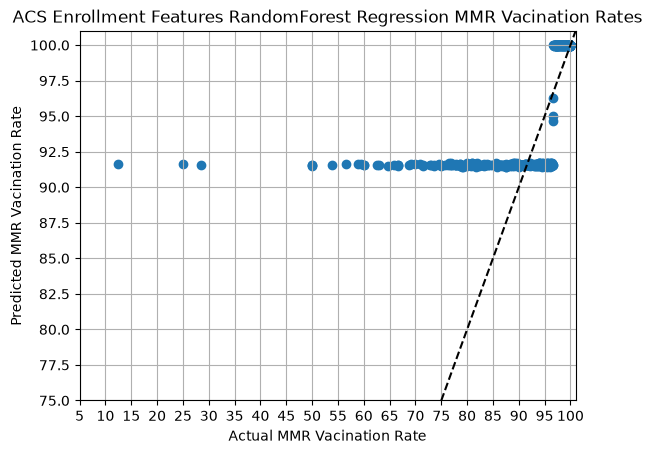

In [ ]:
plot_vac_rates_predicted_actual(y_rf_regr_results, reg_type="RandomForest")
plt.title("ACS Enrollment Features RandomForest Regression MMR Vacination Rates")
plt.ylim(75, 101)
plt.yticks(custom_y_ticks_75_100)
plt.xlim(5, 101)
plt.xticks(custom_x_ticks)
#plt.savefig('../plots/randomForest_regression_vac_rates_acs_enrollment_features_actual_predict.png', bbox_inches="tight")

In [ ]:
all_rf_regr_percent_df_enroll_edu, rf_regr_perform_dict_enroll_edu, y_rf_regr_results_enroll_edu = ml_alogrithm_analysis(enroll_edu_regr, model_type="RandomForest", drop_columns=['County'], 
                                                                         hyper_params=enroll_xgb_params, algorithm_type="Regression")

Mean Absolute Error = 3.9634988888040357, R2 = 0.26528601741568214


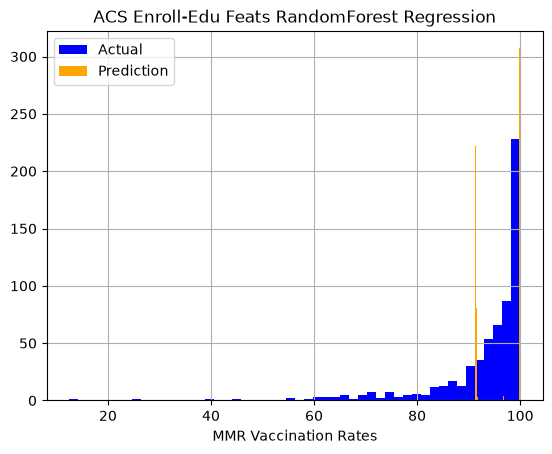

In [9]:
plt.hist(y_rf_regr_results_enroll_edu['test'], color='blue', label='Actual', bins=50)
plt.hist(y_rf_regr_results_enroll_edu['predict'], color='orange', label='Prediction', bins=50)
plt.title("ACS Enroll-Edu Feats RandomForest Regression")
plt.xlabel('MMR Vaccination Rates')
plt.legend()
plt.grid()

([<matplotlib.axis.XTick at 0x221c77146d0>,
 [Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40'),
  Text(45, 0, '45'),
  Text(50, 0, '50'),
  Text(55, 0, '55'),
  Text(60, 0, '60'),
  Text(65, 0, '65'),
  Text(70, 0, '70'),
  Text(75, 0, '75'),
  Text(80, 0, '80'),
  Text(85, 0, '85'),
  Text(90, 0, '90'),
  Text(95, 0, '95'),
  Text(100, 0, '100')])

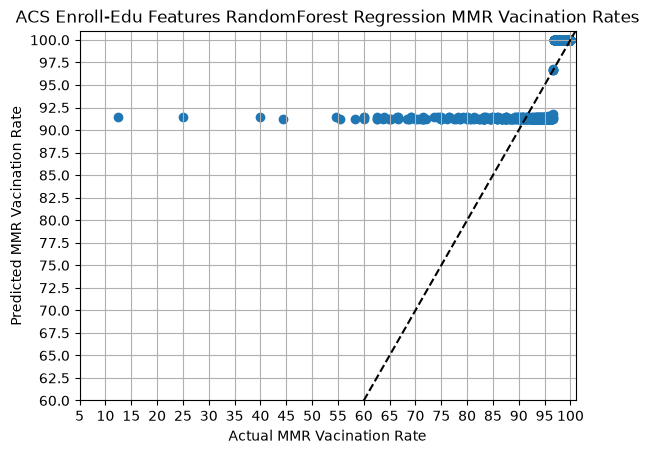

In [10]:
plot_vac_rates_predicted_actual(y_rf_regr_results_enroll_edu, reg_type="RandomForest")
plt.title("ACS Enroll-Edu Features RandomForest Regression MMR Vacination Rates")
plt.ylim(60, 101)
plt.yticks(custom_y_ticks_60_100)
plt.xlim(5, 101)
plt.xticks(custom_x_ticks)

In [ ]:
all_rf_regr_percent_df_enroll_edu_dis_lan_insur, rf_regr_perform_dict_enroll_edu_dis_lan_insur, y_rf_regr_results_enroll_edu_dis_lan_insur = ml_alogrithm_analysis(eeli_regr, model_type="RandomForest", drop_columns=['County'], 
                                                                         estimators=1000, algorithm_type="Regression")

NameError: name 'all_vac_enroll_edu_dis_lang_insur_percent_regression' is not defined

In [ ]:
plot_vac_rates_predicted_actual(eeli_regr, reg_type="RandomForest")
plt.title("ACS Enroll-Edu-Dis-Lang-Insur Feats RandomForest Regression")
plt.ylim(75, 101)
plt.yticks(custom_y_ticks_75_100)
plt.xlim(5, 101)
plt.xticks(custom_x_ticks)

In [ ]:
plt.hist(y_rf_regr_results_enroll_edu_dis_lan_insur['test'], color='blue', label='Actual', bins=50)
plt.hist(y_rf_regr_results_enroll_edu_dis_lan_insur['predict'], color='orange', label='Prediction', bins=50)
plt.title("ACS Enroll-Edu-Dis-Lang-Insur Feats RandomForest Regression")
plt.xlabel('MMR Vaccination Rates')
plt.legend()
plt.grid()

Binary Classification

In [ ]:
#all_rf_class_percent_df_eedli, rf_classBi_perform_dict_eedli, y_rf_classBi_results_eedli = ml_alogrithm_analysis(all_vac_enroll_edu_dis_lang_insur_percent_class_high_low, model_type="RandomForest", drop_columns=['County'], 
#                                                                         estimators=1000, algorithm_type="Classification")

In [ ]:
#all_boost_class_percent_df_eedli, boost_classBi_perform_dict_eedli, y_boost_classBi_results_eedli = ml_alogrithm_analysis(all_vac_enroll_edu_dis_lang_insur_percent_class_high_low, model_type="Boost", drop_columns=['County'], 
#                                                                         estimators=1000, algorithm_type="Classification")

In [ ]:
#class_labels6 = ['0-0.5', '0.5-0.59', '0.60-0.74', '0.75-0.84', '0.85-0.89', '0.9-1.0']
#class_labels2 = ['0-0.531', '0.532-1.0']

In [ ]:
#cm_classBi_rf_eedli = confusion_matrix(y_rf_classBi_results_eedli['test'], y_rf_classBi_results_eedli['predict'])
#sns.heatmap(cm_classBi_rf_eedli, annot=True, xticklabels=class_labels2, yticklabels=class_labels2)
#plt.title("ACS Enrollment RandomForest Confusion Matrix")
#plt.ylabel('Actual')
#plt.xlabel('Predict')

In [ ]:
#cm_classBi_boost_eedli = confusion_matrix(y_boost_classBi_results_eedli['test'], y_boost_classBi_results_eedli['predict'])
#sns.heatmap(cm_classBi_boost_eedli, annot=True, xticklabels=class_labels2, yticklabels=class_labels2)
#plt.title("ACS Enrollment Boost Confusion Matrix")#
#plt.ylabel('Actual')
#plt.xlabel('Predict')

In [ ]:
#all_rf_class_percent_df_ee, rf_classBi_perform_dict_ee, y_rf_classBi_results_ee = ml_alogrithm_analysis(all_vac_enroll_edu_percent_class_high_low, model_type="RandomForest", drop_columns=['County'], 
#                                                                         estimators=1000, algorithm_type="Classification")

In [ ]:
#cm_classBi_rf_ee = confusion_matrix(y_rf_classBi_results_ee['test'], y_rf_classBi_results_ee['predict'])
#sns.heatmap(cm_classBi_rf_ee, annot=True, xticklabels=class_labels2, yticklabels=class_labels2)
#plt.title("ACS Enrollment RandomForest Confusion Matrix")
#plt.ylabel('Actual')
#plt.xlabel('Predict')